# 08 - Rate of descent: the symbolic (exact) approach with SymPy

This notebook mirrors notebook `04_RateOfDescent.ipynb`: gliding flight, the
hodograph, glide distance and time aloft, the "speed to fly" with wind, the
idle descent and the one-engine-inoperative drift-down. Here every formula
is **derived** with SymPy and then checked against the textbooks and against
the numerical package `aircraft_performance`.

References: Roskam & Lan, Sec. 8.2 (un-powered flight), Secs. 9.2.3, 9.4.2
(drift-down), Problem 9.4; Anderson, Sec. 5.11.

The notebook follows the same SymPy best practices as `07_RateOfClimb_Symbolical.ipynb`
(official documentation, *Best Practices* and *Solving Guidance*, SymPy 1.14):
symbols with assumptions, exact rationals, `solve(..., dict=True)` with the
unknown named, targeted simplification instead of `simplify()`, symbols
passed as function arguments, `nsolve`/`nroots`/`Integral.evalf` only when
no closed form exists, and `lambdify` to move from symbols to NumPy.

Run the cells in order (*Run -> Run All Cells*); `check()` stops the notebook
with an error if a result disagrees with its reference value.

In [1]:
# --- Imports ---------------------------------------------------------------
import pathlib
import sys
import warnings

import sympy as sp              # symbolic engine, always used through "sp."
import numpy as np              # numbers only, after lambdify
import matplotlib.pyplot as plt
from IPython.display import Markdown, Math, display  # typeset output in the notebook

# The notebooks live in PrestazioniRoskam/, one level below the repository root,
# where the `aircraft_performance` package is. Make it importable:
ROOT = pathlib.Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# The numerical package is used ONLY for independent cross-checks
from aircraft_performance import descent as num_descent, examples            # noqa: E402
from aircraft_performance.aerodynamics import ParabolicDragPolar             # noqa: E402
from aircraft_performance.aircraft import Aircraft, Configuration           # noqa: E402
from aircraft_performance.atmosphere import isa as num_isa                   # noqa: E402
from aircraft_performance.plotting import apply_style                       # noqa: E402
from aircraft_performance.propulsion import JetPropulsion                    # noqa: E402

apply_style()
print(f"SymPy version: {sp.__version__}")

SymPy version: 1.14.0


In [2]:
# --- Helpers (identical to those of notebook 07, repeated so that this one runs on its own) ---
def show(title, expr):
    """Display a title and a SymPy object as typeset (LaTeX) mathematics.

    sp.latex() converts the expression to LaTeX, which Jupyter renders with
    MathJax; this is the notebook counterpart of sp.pprint().
    """
    display(Markdown(f"**{title}:**"), Math(sp.latex(expr)))


def check(label, computed, reference, rel_tol):
    """Compare a result with a reference value and STOP (raise) if they disagree."""
    computed, reference = float(computed), float(reference)
    rel = abs(computed - reference) / abs(reference)
    if rel > rel_tol:
        raise AssertionError(f"{label}: computed {computed:.6g}, reference {reference:.6g} "
                             f"(difference {100 * rel:.3f} % > {100 * rel_tol:.3f} %)")
    print(f"  [OK] {label}: {computed:.6g}  (reference {reference:.6g}, difference {100 * rel:.3f} %)")


def physical_root(solutions, unknown, sample):
    """Pick the one solution of solve(..., dict=True) that is real and positive at ``sample``.

    SymPy keeps every root whose sign it cannot disprove from the assumptions,
    so we test the candidates at a representative point and refuse ambiguity.
    """
    good = []
    for sol in solutions:
        value = sp.N(sol[unknown].subs(sample), 30)
        if value.is_real and value > 0:
            good.append(sol[unknown])
    if len(good) != 1:
        raise ValueError(f"Expected one physical root, found {len(good)}")
    return good[0]


def is_identically_zero(expr):
    """Targeted zero test for expressions with square roots of positive symbols."""
    reduced = sp.factor(sp.powdenest(sp.expand(expr), force=True))
    return reduced == 0 or bool(reduced.equals(0))

## 1. Equations of the steady glide (Roskam Sec. 8.2.1-8.2.2)

With no thrust, the aerodynamic resultant balances the weight. Calling
$\bar\gamma>0$ the glide angle *below* the horizon:

$$D = W\sin\bar\gamma,\qquad L = W\cos\bar\gamma .$$

In [3]:
W, S, rho = sp.symbols("W S rho", positive=True)          # weight, wing area, density
CD0, K = sp.symbols("C_D0 K", positive=True)              # parabolic polar
CL, V = sp.symbols("C_L V", positive=True)                # lift coefficient, airspeed
gam = sp.Symbol("gamma_bar", positive=True)               # glide angle (0 < gamma < pi/2)
CD = CD0 + K * CL**2                                      # drag coefficient
q = rho * V**2 / 2                                        # dynamic pressure

eq_D = sp.Eq(q * S * CD, W * sp.sin(gam))                 # along the path
eq_L = sp.Eq(q * S * CL, W * sp.cos(gam))                 # normal to the path
show("Drag equation", eq_D)
show("Lift equation", eq_L)

# (a) Dividing the two equations eliminates W, V and rho: the glide angle depends
#     only on the aerodynamic ratio (Roskam Eqn 8.15).
tan_gamma = sp.cancel(eq_D.lhs / eq_L.lhs)                 # = sin/cos of the right-hand sides
show("tan(gamma) = D / L = C_D / C_L", tan_gamma)

# (b) Squaring and adding eliminates the angle: (q S)^2 (CL^2 + CD^2) = W^2.
#     We solve for V exactly (Roskam Eqn 8.16) and let the assumption V > 0
#     select the physical root.
exact_V = sp.solve(sp.Eq((q * S)**2 * (CL**2 + CD**2), W**2), V, dict=True)
V_glide_exact = exact_V[0][V]
show("Exact glide speed V (Roskam Eqn 8.16)", V_glide_exact)

# (c) Small angles (cos gamma ~ 1): V from the lift equation, sink rate RD = V sin(gamma) ~ V C_D / C_L
V_glide = sp.sqrt(2 * W / (rho * S * CL))
RD_of_CL = V_glide * CD / CL
show("Rate of descent, small angles (Roskam Eqn 8.24)", RD_of_CL)

**Drag equation:**

<IPython.core.display.Math object>

**Lift equation:**

<IPython.core.display.Math object>

**tan(gamma) = D / L = C_D / C_L:**

<IPython.core.display.Math object>

**Exact glide speed V (Roskam Eqn 8.16):**

<IPython.core.display.Math object>

**Rate of descent, small angles (Roskam Eqn 8.24):**

<IPython.core.display.Math object>

## 2. The optimum glides, derived

* longest distance: minimum $\tan\bar\gamma$, i.e. maximum $C_L/C_D$ (point E);
* longest time: minimum $RD$, i.e. maximum $C_L^3/C_D^2$ (point P).

Both optima are found by setting a derivative to zero and solving for $C_L$.

In [4]:
SAMPLE = {W: 10000, S: 16, rho: 1, CD0: sp.Rational(3, 100), K: sp.Rational(5, 100)}

CL_E = physical_root(sp.solve(sp.diff(CL / CD, CL), CL, dict=True), CL, SAMPLE)
CL_P = physical_root(sp.solve(sp.diff(RD_of_CL, CL), CL, dict=True), CL, SAMPLE)
show("C_L of the best glide (point E), Roskam Eqn 8.19", CL_E)
show("C_L of the minimum sink (point P), Roskam Eqn 8.26", CL_P)

E_max = sp.radsimp((CL / CD).subs(CL, CL_E))
show("Maximum glide ratio E_max = (C_L/C_D)_max, Roskam Eqn 8.18", E_max)

RD_min = sp.powsimp(sp.radsimp(RD_of_CL.subs(CL, CL_P)), force=True)
show("Minimum rate of descent, Roskam Eqn 8.30", RD_min)

# Exact ratios between the two optima (numbers independent of the aircraft!)
speed_ratio = sp.powsimp(sp.radsimp(V_glide.subs(CL, CL_E) / V_glide.subs(CL, CL_P)), force=True)
sink_ratio = sp.powsimp(sp.radsimp(RD_of_CL.subs(CL, CL_E) / RD_min), force=True)
show("V_E / V_P", speed_ratio)
show("RD at best glide / RD_min", sink_ratio)
print(f"  -> the best-glide speed is {sp.N(speed_ratio, 4)} times the minimum-sink speed, "
      f"with a sink rate {sp.N(100 * (sink_ratio - 1), 3)} % higher.")

**C_L of the best glide (point E), Roskam Eqn 8.19:**

<IPython.core.display.Math object>

**C_L of the minimum sink (point P), Roskam Eqn 8.26:**

<IPython.core.display.Math object>

**Maximum glide ratio E_max = (C_L/C_D)_max, Roskam Eqn 8.18:**

...

**V_E / V_P:**

<IPython.core.display.Math object>

**RD at best glide / RD_min:**

<IPython.core.display.Math object>

  -> the best-glide speed is 1.316 times the minimum-sink speed, with a sink rate 14.0 % higher.


### 2.1 Checks against the textbooks

* Roskam's glider (p. 341): $A = 15.6$, $e = 0.82$, $C_{D_0} = 0.015$,
  $W = 300$ kg, $S = 14.1$ m², sea level: best glide at **20.9 m/s**.
* Anderson Examples 5.14-5.15 (Gulfstream IV at 30,000 ft, British units):
  $\bar\gamma_{min} = 3.964°$, sink 43.6 ft/s at best glide, minimum sink
  38.6 ft/s (Anderson rounds $(C_L^{3/2}/C_D)_{max}$ to 10.83).

In [5]:
G0 = sp.Rational("9.80665")
glider = {W: 300 * G0, S: sp.Rational("14.1"), rho: sp.Rational("1.225"), CD0: sp.Rational("0.015"),
          K: 1 / (sp.pi * sp.Rational("15.6") * sp.Rational("0.82"))}
check("Roskam glider: best-glide speed [m/s]", V_glide.subs(CL, CL_E).evalf(10, subs=glider), 20.9, 3e-3)

rho30k = sp.Rational("0.00089068")                  # slug/ft^3 at 30,000 ft (Anderson, Appendix B)
giv = {W: 73000, S: 950, rho: rho30k, CD0: sp.Rational("0.015"), K: sp.Rational("0.08")}
gamma_min_deg = sp.deg(sp.atan(1 / E_max)).evalf(10, subs=giv)
check("Anderson 5.14: minimum glide angle [deg]", gamma_min_deg, 3.964, 5e-4)
check("Anderson 5.15: sink rate at best glide [ft/s]",
      (V_glide * sp.sin(sp.atan(CD / CL))).subs(CL, CL_E).evalf(10, subs=giv), 43.6, 3e-3)
check("Anderson 5.15: minimum sink rate [ft/s]", RD_min.evalf(10, subs=giv), 38.6, 1.5e-2)

  [OK] Roskam glider: best-glide speed [m/s]: 20.9466  (reference 20.9, difference 0.223 %)
  [OK] Anderson 5.14: minimum glide angle [deg]: 3.96323  (reference 3.964, difference 0.019 %)
  [OK] Anderson 5.15: sink rate at best glide [ft/s]: 43.6299  (reference 43.6, difference 0.069 %)
  [OK] Anderson 5.15: minimum sink rate [ft/s]: 38.3719  (reference 38.6, difference 0.591 %)


## 3. The hodograph as an explicit curve RD(V)

Eliminating $C_L$ between $V$ and $RD$ (small angles) gives the speed polar as
an explicit function (substitute $C_L = 2W/(\rho V^2 S)$):

$$RD(V) = \underbrace{\frac{\rho S C_{D_0}}{2W}}_{a}V^3 + \underbrace{\frac{2KW}{\rho S}}_{b}\frac1V .$$

Geometrically (Roskam Figs. 8.7-8.8): the **tangent from the origin** touches
the curve at the best glide (minimum $RD/V$), the **highest point** is the
minimum sink (minimum $RD$). We verify both properties symbolically.

In [6]:
RD_of_V = sp.expand(RD_of_CL.subs(CL, 2 * W / (rho * V**2 * S)))
show("Hodograph RD(V)", RD_of_V)

x = sp.Symbol("x", positive=True)                       # x = V^2 (the conditions are polynomials in V^2)
V2_tangent = physical_root(sp.solve(sp.numer(sp.together(sp.diff(RD_of_V / V, V).subs(V, sp.sqrt(x)))),
                                    x, dict=True), x, SAMPLE)
V2_top = physical_root(sp.solve(sp.numer(sp.together(sp.diff(RD_of_V, V).subs(V, sp.sqrt(x)))),
                                x, dict=True), x, SAMPLE)
if not is_identically_zero(V2_tangent - V_glide.subs(CL, CL_E)**2):
    raise AssertionError("tangent from the origin is not the best-glide point")
if not is_identically_zero(V2_top - V_glide.subs(CL, CL_P)**2):
    raise AssertionError("highest point of the hodograph is not the minimum-sink point")
print("  [OK] tangent from the origin = point E, highest point = point P (exact identities)")

**Hodograph RD(V):**

<IPython.core.display.Math object>

  [OK] tangent from the origin = point E, highest point = point P (exact identities)


## 4. Glide distance and time aloft

### 4.1 Distance: independent of altitude and weight

At constant $C_L$ the path angle is constant, so the still-air distance from
a height $h_0$ is $R = h_0/\tan\bar\gamma = h_0\,E$ (Roskam Eqn 8.28): the
density does not appear, although the *speed* changes during the descent.

### 4.2 Time aloft: integrating the real atmosphere

The sink rate scales as $1/\sqrt\rho$: $RD(h) = RD_{SL}/\sqrt{\sigma(h)}$.
In the troposphere $\sigma = (1 - \lambda h)^{n}$, with $\lambda = L/T_0$ and
$n = g/(LR) - 1$, hence

$$t = \int_0^{h_0}\frac{dh}{RD(h)} = \frac{1}{RD_{SL}}\int_0^{h_0}(1-\lambda h)^{n/2}\,dh .$$

As in file 07 we substitute $u = 1-\lambda h$ and integrate down to a
*positive* symbol $r = 1-\lambda h_0$, so that SymPy returns a clean closed form.

In [7]:
lam, n_exp, RD_SL, h0 = sp.symbols("lambda n RD_SL h_0", positive=True)
u, r = sp.symbols("u r", positive=True)                  # u = 1 - lambda h, r = 1 - lambda h0 > 0
integral_u = sp.integrate(u**(n_exp / 2) / lam, (u, r, 1))    # dh = -du / lambda
integral_u = sp.piecewise_fold(integral_u)
# With n > 0 the exponent n/2 + 1 can never vanish: pick the generic branch of any Piecewise
if isinstance(integral_u, sp.Piecewise):
    integral_u = next(expr for expr, cond in integral_u.args if cond is not sp.true or len(integral_u.args) == 1)
t_aloft = sp.powsimp(sp.cancel(integral_u / RD_SL).subs(r, 1 - lam * h0))   # combine equal bases
show("Time aloft integrated through the troposphere", t_aloft)

# Exact ISA constants of the troposphere (rationals); the exponent n is converted
# to a 30-digit Float before use (see file 07: exact powers with a ~20-digit
# rational exponent are needlessly slow).
L_T, T0, R_air = sp.Rational("0.0065"), sp.Rational("288.15"), sp.Rational("287.05287")
DIGITS = 30
n_isa = sp.Float(G0 / (L_T * R_air) - 1, DIGITS)
lam_isa = L_T / T0

# The numerical package integrates the EXACT glide (L = W cos(gamma)). How much does
# the small-angle sink rate differ from the exact one at the same C_L? Using the
# exact speed of Section 1(b), RD_exact = V_exact * sin(gamma) with
# tan(gamma) = C_D / C_L, the ratio reduces to cos(gamma)^(3/2): a constant
# along a constant-C_L descent, so it simply rescales the time.
# A generic positive symbol for C_D keeps the result readable (the polar would
# only expand it); the parabolic polar is substituted afterwards.
Cd = sp.Symbol("C_D", positive=True)
V_exact_generic = sp.sqrt(2 * W / (rho * S * sp.sqrt(CL**2 + Cd**2)))      # Section 1(b)
RD_exact_generic = V_exact_generic * Cd / sp.sqrt(CL**2 + Cd**2)          # V sin(gamma), sin = C_D / C_R
RD_small_generic = sp.sqrt(2 * W / (rho * S * CL)) * Cd / CL
ratio_generic = sp.powsimp(sp.radsimp(RD_exact_generic / RD_small_generic), force=True)
show("RD_exact / RD_small-angle  ( = cos(gamma)^(3/2), with cos(gamma) = C_L / sqrt(C_L^2 + C_D^2) )",
     ratio_generic)
ratio_exact_small = ratio_generic.subs(Cd, CD)                            # back to the parabolic polar

single = examples.light_single_piston()
pol = single.polar()
single_data = {W: sp.Rational(1100) * G0, S: 16, rho: sp.Rational("1.225"),
               CD0: sp.Rational("0.030"), K: sp.nsimplify(pol.K)}
RD_sl_single = RD_min.subs(single_data)
rows = []
for h_start in (1000, 3000, 6000):
    t_exact = t_aloft.subs({lam: lam_isa, n_exp: n_isa, RD_SL: RD_sl_single, h0: h_start})
    sigma_top = (1 - lam_isa * h_start)**n_isa
    t_top = h_start / (RD_sl_single / sp.sqrt(sigma_top))      # Roskam Eqn 8.31 with rho(h_start)
    t_pkg = num_descent.glide_time(single.weight, single.wing_area, pol, float(h_start))
    rows.append((h_start, sp.N(t_top / 60, 5), sp.N(t_exact / 60, 5), t_pkg / 60))
    # exact-angle correction: divide the time by the (constant) sink-rate ratio at point P
    correction = ratio_exact_small.subs(CL, CL_P).subs(single_data)
    check(f"time aloft from {h_start} m (angle-corrected) vs numerical package [s]",
          (t_exact / correction).evalf(), t_pkg, 1e-5)
print("\n h_start [m]   Eqn 8.31 with rho(h_start) [min]   exact integral [min]   package [min]")
for row in rows:
    print(f"   {row[0]:>6}        {row[1]:>10}                      {row[2]:>10}          {row[3]:8.3f}")
print("The exact time is LONGER than the estimate made with the density of the starting altitude:\n"
      "the aircraft sinks more slowly in the denser air below.")

**Time aloft integrated through the troposphere:**

<IPython.core.display.Math object>

**RD_exact / RD_small-angle  ( = cos(gamma)^(3/2), with cos(gamma) = C_L / sqrt(C_L^2 + C_D^2) ):**

<IPython.core.display.Math object>

  [OK] time aloft from 1000 m (angle-corrected) vs numerical package [s]: 369.068  (reference 369.068, difference 0.000 %)


  [OK] time aloft from 3000 m (angle-corrected) vs numerical package [s]: 1054.6  (reference 1054.6, difference 0.000 %)
  [OK] time aloft from 6000 m (angle-corrected) vs numerical package [s]: 1958.28  (reference 1958.28, difference 0.000 %)

 h_start [m]   Eqn 8.31 with rho(h_start) [min]   exact integral [min]   package [min]
     1000            5.9648                          6.1126             6.151
     3000            16.183                          17.467            17.577
     6000            27.570                          32.433            32.638
The exact time is LONGER than the estimate made with the density of the starting altitude:
the aircraft sinks more slowly in the denser air below.


## 5. Speed to fly with wind (Roskam Sec. 8.2.4.4)

With a headwind $V_w$ and a vertical air velocity $w$ (positive upwards) the
ground glide ratio is

$$G(V) = \frac{V - V_w}{RD(V) - w}.$$

The optimum satisfies $G'(V) = 0$, i.e. $RD - w - (V - V_w)RD'(V) = 0$.
Multiplying by $V^2$ this becomes a **polynomial of degree five** in $V$.
By the Abel-Ruffini theorem a general quintic has no solution in radicals:
the Solving Guidance recommends a numerical root finder. We use
`Poly.nroots()` on the polynomial with the numbers substituted, and keep the
real root with $V > V_w$. In still air the quintic factorises and the
optimum is exactly the best-glide speed: we check that too.

In [8]:
a_c, b_c, Vw, w_up = sp.symbols("a b V_w w", real=True)
RD_generic = a_c * V**3 + b_c / V                        # hodograph with generic a, b
stationary = sp.expand((RD_generic - w_up - (V - Vw) * sp.diff(RD_generic, V)) * V**2)
quintic = sp.Poly(stationary, V)
show("Stationarity condition (polynomial in V)", quintic.as_expr())
print(f"  degree = {quintic.degree()}")

# Still air: V_w = w = 0 -> the polynomial factorises and gives V^4 = b / a (best glide)
still_air = sp.factor(quintic.as_expr().subs({Vw: 0, w_up: 0}))
show("Still air: factorised condition", still_air)

# Numerical coefficients a, b for the light single at 1,000 m
rho1000 = sp.Float(num_isa(1000.0).density, DIGITS)
# NOTE: build a new dictionary with the density at 1,000 m. Substituting
# single_data first and rho afterwards would silently keep the sea-level
# density (single_data already fixes rho) - subs() applies replacements in order.
single_1000 = {**single_data, rho: rho1000}
coeffs = {a_c: (rho * S * CD0 / (2 * W)).subs(single_1000),
          b_c: (2 * K * W / (rho * S)).subs(single_1000)}
cases = [("still air", 0, 0), ("headwind 10 m/s", 10, 0), ("tailwind 10 m/s", -10, 0),
         ("sinking air 1.5 m/s", 0, sp.Rational(-3, 2)), ("rising air 1 m/s", 0, 1)]
print("\n condition              V_opt [m/s]   ground glide ratio   package V [m/s]")
for label, hw, wz in cases:
    poly_num = sp.Poly(quintic.as_expr().subs({**coeffs, Vw: hw, w_up: wz}), V)
    roots = [complex(z) for z in poly_num.nroots(n=15)]   # all five roots, numerically
    V_opt = max(z.real for z in roots if abs(z.imag) < 1e-9 and z.real > max(hw, 0))
    G_opt = (V_opt - hw) / float((RD_generic.subs(coeffs).subs(V, V_opt)) - wz)
    pkg = num_descent.best_glide_with_wind(single.weight, single.wing_area, float(rho1000), pol,
                                          single.config().CL_max, headwind=hw, updraft=float(wz))
    print(f" {label:<22} {V_opt:10.2f}   {G_opt:18.3f}   {pkg['state'].V:14.2f}")
    check(f"speed to fly, {label} (small-angle vs exact package) [m/s]", V_opt, pkg["state"].V, 1e-2)

**Stationarity condition (polynomial in V):**

<IPython.core.display.Math object>

  degree = 5


**Still air: factorised condition:**

<IPython.core.display.Math object>


 condition              V_opt [m/s]   ground glide ratio   package V [m/s]
 still air                   40.08               12.585            40.02
  [OK] speed to fly, still air (small-angle vs exact package) [m/s]: 40.0795  (reference 40.0165, difference 0.157 %)


 headwind 10 m/s             43.24                9.564            43.18
  [OK] speed to fly, headwind 10 m/s (small-angle vs exact package) [m/s]: 43.2355  (reference 43.1761, difference 0.137 %)
 tailwind 10 m/s             38.04               15.807            37.97
  [OK] speed to fly, tailwind 10 m/s (small-angle vs exact package) [m/s]: 38.0399  (reference 37.9674, difference 0.191 %)
 sinking air 1.5 m/s         44.53                8.702            44.46
  [OK] speed to fly, sinking air 1.5 m/s (small-angle vs exact package) [m/s]: 44.5263  (reference 44.4567, difference 0.157 %)
 rising air 1 m/s            36.81               18.711            36.72
  [OK] speed to fly, rising air 1 m/s (small-angle vs exact package) [m/s]: 36.8113  (reference 36.724, difference 0.238 %)


## 6. Idle descent at constant equivalent airspeed

At constant EAS the dynamic pressure is constant, hence $C_L$, $C_D$ and the
**drag are constant** during the whole descent (small angles, $L\approx W$).
With idle thrust $T=0$:

* the descent gradient is constant: $\tan\bar\gamma = D/W$, so the horizontal
  distance is exactly $\Delta s = (W/D)\,\Delta h$;
* the sink rate is $RD = D\,V/W = D V_e/(W\sqrt\sigma)$, so the time is
  $\frac{W}{DV_e}\int\sqrt{\sigma}\,dh$ - **the same integral as the time aloft**.

In [9]:
Ve = sp.Symbol("V_e", positive=True)
D_const = (rho * Ve**2 / 2 * S * (CD0 + K * (W / (rho * Ve**2 / 2 * S))**2))   # rho = rho_SL here
h_top, h_bot = sp.symbols("h_top h_bot", positive=True)
distance = sp.cancel(W / D_const * (h_top - h_bot))
show("Horizontal distance of the idle descent", distance)

# time = W/(D Ve) * [I(h_top) - I(h_bot)] with I(h) = integral_0^h sqrt(sigma) dh = RD_SL * t_aloft(h)
I_of = lambda hh: (t_aloft * RD_SL).subs({lam: lam_isa, n_exp: n_isa, h0: hh})   # noqa: E731
jet = examples.business_jet_giv()
jet_data = {W: sp.nsimplify(0.75 * jet.weight), S: sp.nsimplify(jet.wing_area), rho: sp.Rational("1.225"),
            CD0: sp.Rational("0.015"), K: sp.Rational("0.08"), Ve: 140}
time_descent = (W / (D_const * Ve)).subs(jet_data) * (I_of(11000) - I_of(1000))
dist_descent = distance.subs(jet_data).subs({h_top: 11000, h_bot: 1000})
pkg = num_descent.descent_at_constant_eas(jet, 11000.0, 1000.0, 140.0, weight=0.75 * jet.weight, n_steps=200)
print(f"Idle descent 11,000 -> 1,000 m at 140 m/s EAS: {sp.N(time_descent / 60, 5)} min, "
      f"{sp.N(dist_descent / 1000, 5)} km")
check("idle descent time vs numerical package [s]", time_descent.evalf(), pkg.total_time, 2e-3)
check("idle descent distance vs numerical package [m]", dist_descent.evalf(), pkg.total_distance, 1e-2)

**Horizontal distance of the idle descent:**

<IPython.core.display.Math object>

Idle descent 11,000 -> 1,000 m at 140 m/s EAS: 10.515 min, 119.55 km
  [OK] idle descent time vs numerical package [s]: 630.917  (reference 630.916, difference 0.000 %)
  [OK] idle descent distance vs numerical package [m]: 119550  (reference 119550, difference 0.000 %)


## 7. One engine inoperative: drift-down (Roskam Sec. 9.4.2, Problem 9.4c)

Twin business jet of Roskam Problem 9.4: $W = 16{,}000$ lb, $S = 200$ ft²,
OEI polar $C_D = 0.0190 + 0.023C_L^2$, each engine 2,400 lb at sea level and
800 lb at 40,000 ft ($T = T_{SL}\sigma^m$). After an engine failure at
40,000 ft the aircraft drifts down at the speed of minimum rate of descent.

The minimum rate of descent is minus the maximum rate of climb, whose closed
form (constant thrust, parabolic polar) was derived in file 07; we re-derive
it here in two lines. Then:

1. the **OEI absolute ceiling** ($RD_{min} = 0$) in closed form;
2. the altitude where $RD_{min}$ drops to the practical floor of 100 ft/min
   and the OEI cruise altitude ($RC = +100$ ft/min) with `nsolve`;
3. the drift-down time as an integral, split by atmospheric layer, plus the
   final segment flown at the 100 ft/min floor (Roskam Table 9.8 procedure).

In [10]:
T = sp.Symbol("T", positive=True)
drag_V = sp.expand(q * S * CD0 + K * W**2 / (q * S))                  # level-flight drag D(V)
RC_V = (T - drag_V) * V / W
V2_best = physical_root(sp.solve(sp.numer(sp.together(sp.diff(RC_V, V).subs(V, sp.sqrt(x)))), x, dict=True),
                        x, {**SAMPLE, T: 2000})
RC_max = RC_V.subs(V, sp.sqrt(V2_best))
RD_min_powered = -RC_max                                               # minimum rate of descent
show("Speed^2 of minimum rate of descent (= best-RC speed^2)", V2_best)

# Problem 9.4 data (British units: lb, ft, slug/ft^3, ft/s). The weight W stays
# a symbol for now: we will study two weights.
FT = sp.Rational(3048, 10000)
sig, m_exp = sp.symbols("sigma m", positive=True)
p94 = {S: 200, CD0: sp.Rational("0.019"), K: sp.Rational("0.023")}
sigma_40k = sp.Float(num_isa(float(40000 * FT)).sigma, DIGITS)
m94 = sp.log(sp.Rational(1, 3)) / sp.log(sigma_40k)                    # 2400 sigma^m = 800 at 40,000 ft
print(f"\nThrust lapse exponent m = {sp.N(m94, 6)}")
# One engine: T = 2400 sigma^m lb; density rho = rho_SL sigma
RD_of_sigma = RD_min_powered.subs({T: 2400 * sig**m_exp, rho: sp.Rational("0.002377") * sig}).subs(p94)

# (1) OEI absolute ceiling in closed form: T(sigma) = W / E_max
sigma_ceiling = sp.solve(sp.Eq(2400 * sig**m_exp, W / E_max), sig, dict=True)[0][sig]
show("sigma at the OEI absolute ceiling", sigma_ceiling)
print(f"E_max with the OEI polar = {sp.N(E_max.subs(p94), 5)}  (high: the polar ignores compressibility)")


def altitude_from_sigma(sigma_value):
    """Inverse ISA for a numerical density ratio, troposphere and 11-20 km layer [m]."""
    sigma11 = (1 - lam_isa * 11000)**n_isa
    if sigma_value >= sigma11:
        return (1 - sigma_value**(1 / n_isa)) / lam_isa
    T11 = T0 - L_T * 11000
    return 11000 + R_air * T11 / G0 * sp.log(sigma11 / sigma_value)

**Speed^2 of minimum rate of descent (= best-RC speed^2):**

<IPython.core.display.Math object>


Thrust lapse exponent m = 0.783753


**sigma at the OEI absolute ceiling:**

<IPython.core.display.Math object>

E_max with the OEI polar = 23.918  (high: the polar ignores compressibility)


Why a floor of 100 ft/min? Near the ceiling $RD_{min}$ vanishes linearly,
$RD \approx k\,(h-h_c)$, and the time integral diverges logarithmically:

In [11]:
k_slope, zeta, H = sp.symbols("k zeta H", positive=True)
show("integral_0^H dzeta / (k zeta)  (time to reach the ceiling exactly)",
     sp.integrate(1 / (k_slope * zeta), (zeta, 0, H)))

**integral_0^H dzeta / (k zeta)  (time to reach the ceiling exactly):**

<IPython.core.display.Math object>

The whole procedure is collected in one function, which receives the weight
and the start altitude as arguments. It checks the order of the altitudes
before integrating: if the aircraft is already below its OEI ceiling there is
nothing to integrate and it says so, instead of returning a meaningless
(e.g. negative) time.

Steps: OEI ceiling (closed form) -> altitude where $RD_{min}$ = 100 ft/min and
OEI cruise altitude where $RC$ = +100 ft/min (`nsolve`) -> integral of
$dh/RD_{min}$ from the start altitude down to the floor altitude, split at the
tropopause -> last segment flown at 100 ft/min (Roskam Table 9.8 procedure).

In [12]:
hm = sp.Symbol("h_m", positive=True)                                   # altitude [m]
T11 = T0 - L_T * 11000
sigma11 = (1 - lam_isa * 11000)**n_isa
sigma_tropo = (1 - lam_isa * hm)**n_isa                                # 0-11 km
sigma_iso = sigma11 * sp.exp(-G0 * (hm - 11000) / (R_air * T11))       # 11-20 km
rd_floor = sp.Rational(100, 60)                                        # 100 ft/min in ft/s


def drift_down_symbolic(weight_lb, h_start_ft):
    """OEI drift-down of the Problem 9.4 jet. Returns a dict, or None if no drift-down is needed."""
    RDs = RD_of_sigma.subs({W: weight_lb, m_exp: m94})                  # ft/s as a function of sigma
    sigma_c = sp.N(sigma_ceiling.subs(p94).subs({W: weight_lb, m_exp: m94}), DIGITS)
    h_c = altitude_from_sigma(sigma_c)
    h_start = h_start_ft * FT
    sigma_cruise = sp.nsolve(RDs + rd_floor, sig, sp.N(sigma_c * sp.Rational(11, 10)))   # RC = +100 ft/min
    h_oei = altitude_from_sigma(sigma_cruise)
    print(f"  W = {weight_lb} lb: OEI absolute ceiling {sp.N(h_c / FT, 6)} ft, "
          f"OEI cruise altitude (RC = 100 ft/min) {sp.N(h_oei / FT, 6)} ft")
    if h_start <= h_oei:
        print(f"  -> the start altitude {h_start_ft} ft is below the OEI cruise altitude: no drift-down needed.")
        return None
    sigma_floor = sp.nsolve(RDs - rd_floor, sig, sp.N(sigma_c * sp.Rational(9, 10)))    # RD = +100 ft/min
    h_floor = min(altitude_from_sigma(sigma_floor), h_start)          # cannot start below the start altitude
    rd_ms = lambda sigma_expr: RDs.subs(sig, sigma_expr) * FT          # noqa: E731  ft/s -> m/s
    t_integral = 0
    for sigma_expr, h_lo, h_hi in ((sigma_tropo, h_floor, min(sp.Integer(11000), h_start)),
                                   (sigma_iso, max(sp.Integer(11000), h_floor), h_start)):
        if sp.N(h_hi) > sp.N(h_lo):                                    # skip layers not crossed
            t_integral += sp.Integral(1 / rd_ms(sigma_expr), (hm, h_lo, h_hi)).evalf(12)
    t_floor = (h_floor - h_oei) / (rd_floor * FT)
    print(f"  RD_min = 100 ft/min at {sp.N(h_floor / FT, 6)} ft. Drift-down time: {sp.N(t_integral / 60, 5)} min "
          f"(integral) + {sp.N(t_floor / 60, 5)} min (at 100 ft/min) = {sp.N((t_integral + t_floor) / 60, 5)} min")
    return {"h_oei": h_oei, "time": t_integral + t_floor}


def package_aircraft(weight_lb):
    """The same jet for the numerical package (SI units)."""
    return Aircraft(
        "Roskam Problem 9.4 twin jet (OEI polar)", mass=weight_lb * 0.45359237, wing_area=200 * 0.3048**2,
        wing_span=31.6 * 0.3048,
        configurations={"clean": Configuration(ParabolicDragPolar(0.019, 0.023), 1.4)},
        propulsion=JetPropulsion(4800 * 4.4482216152605, 1e-4, n_engines=2, lapse_exponent=float(m94)))

### 7(a) Problem 9.4 as stated: W = 16,000 lb, engine failure at 40,000 ft

With this Mach-independent polar the OEI lift-to-drag ratio is about 24, so
a single engine can hold the aircraft *above* 40,000 ft: no drift-down. The
numerical package reaches the same conclusion and raises
`InfeasibleFlightConditionError` - it refuses to integrate a descent that
does not exist.

In [13]:
from aircraft_performance.errors import InfeasibleFlightConditionError   # noqa: E402
result_16k = drift_down_symbolic(16000, 40000)
try:
    num_descent.drift_down(package_aircraft(16000), float(40000 * FT), n_operative=1)
    raise AssertionError("the package should have reported that no drift-down is needed")
except InfeasibleFlightConditionError as err:
    print(f"  [OK] numerical package agrees: {err}")
assert result_16k is None

  W = 16000 lb: OEI absolute ceiling 44749.4 ft, OEI cruise altitude (RC = 100 ft/min) 43027.4 ft
  -> the start altitude 40000 ft is below the OEI cruise altitude: no drift-down needed.


  [OK] numerical package agrees: h_start = 12192 m is below the OEI ceiling (13115 m): no drift-down.


### 7(b) A heavier variant: W = 24,000 lb

At a higher weight the OEI ceiling drops below 40,000 ft and the aircraft
must drift down. The symbolic result is compared with the package's
trapezoidal integration (same 100 ft/min floor).

In [14]:
result_24k = drift_down_symbolic(24000, 40000)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    dd = num_descent.drift_down(package_aircraft(24000), float(40000 * FT), n_operative=1, n_steps=400)
check("OEI cruise altitude vs numerical package [m]", result_24k["h_oei"], dd.final_altitude, 1e-3)
check("drift-down time vs numerical package [s]", result_24k["time"], dd.total_time, 1e-2)

  W = 24000 lb: OEI absolute ceiling 33460.4 ft, OEI cruise altitude (RC = 100 ft/min) 31133.5 ft


  RD_min = 100 ft/min at 35735.9 ft. Drift-down time: 22.331 min (integral) + 46.024 min (at 100 ft/min) = 68.354 min


  [OK] OEI cruise altitude vs numerical package [m]: 9489.5  (reference 9489.52, difference 0.000 %)
  [OK] drift-down time vs numerical package [s]: 4101.27  (reference 4132.57, difference 0.758 %)


## 8. From symbols to a plot: the hodograph with `lambdify`

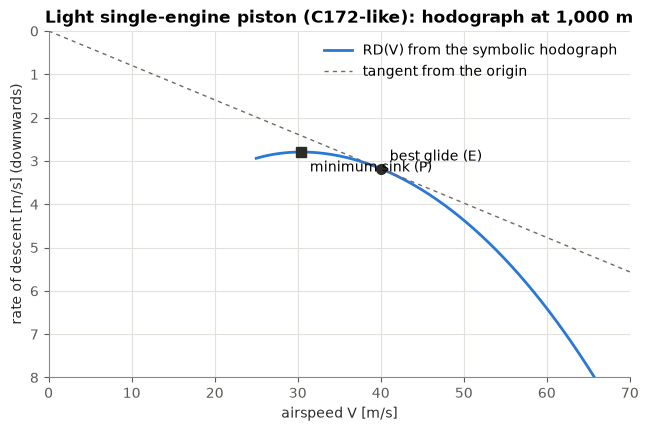


All symbolic results reproduced the reference values.


In [15]:
rd_fun = sp.lambdify(V, RD_of_V.subs(single_1000), modules="numpy")
speeds = np.linspace(25.0, 70.0, 200)
VE = float(V_glide.subs(CL, CL_E).subs(single_1000))
VP = float(V_glide.subs(CL, CL_P).subs(single_1000))
fig, ax = plt.subplots()
ax.plot(speeds, rd_fun(speeds), label="RD(V) from the symbolic hodograph")
ax.plot([0, 70], [0, 70 * rd_fun(VE) / VE], color="#6b6b66", linewidth=1, linestyle=(0, (3, 3)),
        label="tangent from the origin")
ax.plot(VE, rd_fun(VE), "o", color="#2b2b28")
ax.annotate("best glide (E)", (VE, rd_fun(VE)), xytext=(6, 6), textcoords="offset points")
ax.plot(VP, rd_fun(VP), "s", color="#2b2b28")
ax.annotate("minimum sink (P)", (VP, rd_fun(VP)), xytext=(6, -14), textcoords="offset points")
ax.invert_yaxis()
ax.set_xlim(0, 70)
ax.set_ylim(8, 0)
ax.set_xlabel("airspeed V [m/s]")
ax.set_ylabel("rate of descent [m/s] (downwards)")
ax.set_title(f"{single.name}: hodograph at 1,000 m")
ax.legend()
plt.show()

print("\nAll symbolic results reproduced the reference values.")

## 9. Exercises

1. Include the exact relation $L = W\cos\bar\gamma$ in Section 2 (use the exact
   glide speed of Section 1b) and quantify the error of the small-angle
   minimum sink for the Gulfstream IV-like jet.
2. Derive the speed to fly in rising air ($V_w = 0$, $w>0$) as a series in $w$
   with `sp.series` (the first-order MacCready correction).
3. Repeat Section 7 with a 20 % larger windmilling drag ($C_{D_0} = 0.0228$):
   how much lower is the OEI cruise altitude?